# Q-MAML for the scalar Yukawa coupling (single-site, reformulated as a ground-state problem)

**Why this notebook needed a reformulation, but a simple one.** The source paper (Kaldenbach, Heller,
Alber & Stojanovic, "Digital Quantum Simulation of Scalar Yukawa Coupling", arXiv:2211.02684) studies
real-time dynamics after a Yukawa-interaction quench (Loschmidt echo, boson-number growth), not a VQE
ground-state search -- the same kind of gap Track E had to bridge. Unlike Track E, the fix here is direct:
the same Hamiltonian's ground state is a perfectly standard VQE target, and the paper's own Hamiltonian
(their Eqs. 6-7, quoted directly, not re-derived) is simple enough to have a closed-form analytic
cross-check available (see `hamiltonians_yukawa.py`'s docstring) -- something most tracks in this project
don't have.

**The Hamiltonian**: $H = M(a^\dagger a+c^\dagger c) + m b^\dagger b + \frac{\eta}{2}(a^\dagger a+c^\dagger
c-1)(b+b^\dagger)$, $a$/$c$ = fermion/antifermion occupation (2 qubits), $b$ = boson (truncated to
$\Lambda=4$, matching the source paper's own "up to three bosons" showcase scale). Task parameters:
coupling $\eta$, boson mass $m$ (fermion mass $M$ fixed).

**The analytic cross-check**: fixing the fermion sector to vacuum, $H$ reduces exactly to a displaced
harmonic oscillator with known ground energy $E_0=-(\eta/2)^2/m$ on the *untruncated* Fock space. At our
$\Lambda=4$ truncation this is approached, not matched exactly, so the task-parameter range is chosen to
keep $\eta/(2m)$ small enough that truncation error stays under ~1% -- verified directly in Section 0,
with the error's growth outside that range also shown (not hidden) as a documented limitation.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_yukawa import (yukawa_hamiltonian, exact_ground_energy, analytic_vacuum_sector_ground_energy,
                                  sample_task_space, verify_construction, NUM_QUBITS, N_BOSON_QUBITS)
from yukawa_qmaml import classical_init, YukawaPQC, pretrain_learner_yukawa, adapt_task_yukawa
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "yukawa"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS, f"(2 fermion + {N_BOSON_QUBITS} boson)")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\yukawa
NUM_QUBITS = 4 (2 fermion + 2 boson)


## 0. Verify the Hamiltonian construction

Hermiticity; numeric ground energy vs. the analytic displaced-harmonic-oscillator formula at increasing
$\eta/(2m)$ (small-$\alpha$ points inside our sampled task range must match to <1%; a point outside that
range is shown too, informationally, to make the truncation error's growth visible rather than hide it);
the numerically found ground state's measured fermion occupation is exactly 0 (the vacuum sector really is
the global minimum for physically reasonable parameters, not merely assumed).

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  eta=0.3 m=1.8 alpha=0.08: Hermiticity err=0.00e+00, E0 numeric=-0.012500 vs. analytic=-0.012500 (rel err=0.00%)  OK
  eta=0.6 m=1.5 alpha=0.20: Hermiticity err=0.00e+00, E0 numeric=-0.059999 vs. analytic=-0.060000 (rel err=0.00%)  OK
  eta=1.0 m=1.0 alpha=0.50: Hermiticity err=0.00e+00, E0 numeric=-0.249537 vs. analytic=-0.250000 (rel err=0.19%)  OK
  eta=2.0 m=1.0 alpha=1.00: Hermiticity err=0.00e+00, E0 numeric=-0.956033 vs. analytic=-1.000000 (rel err=4.40%)  [outside sampled range, informational]  OK
  Ground state fermion occupation <n_a+n_c>=0.000000 (want 0, vacuum sector)  OK
construction check: PASSED


## 1. Task space: train on a parameter grid, test on held-out points

$p(T)$ is uniform over $\eta\in[0.2,1.0]$, $m\in[1.0,2.0]$ (chosen to keep $\eta/(2m)\le0.5$, inside the
truncation's <1%-error regime per Section 0). Train and test tasks are sampled with different seeds
(held-out interpolation), as in every other track.

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.01
ADAPT_ITERS = 150
ADAPT_LR = 0.05
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (eta,m):", np.round(train_tasks, 3).tolist())
print("test  (eta,m):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(yukawa_hamiltonian(eta, m)) for eta, m in test_tasks]
test_E0_analytic = [analytic_vacuum_sector_ground_energy(eta, m) for eta, m in test_tasks]
print("exact (truncated) test ground energies:", [round(e, 4) for e in test_E0])
print("analytic (untruncated) test ground energies:", [round(e, 4) for e in test_E0_analytic])

train (eta,m): [[0.71, 1.863], [0.416, 1.541], [0.233, 1.3], [0.213, 1.423], [0.851, 1.028], [0.93, 1.124], [0.685, 1.671], [0.784, 1.647], [0.635, 1.615], [0.948, 1.384], [0.853, 1.997], [0.202, 1.981], [0.886, 1.686], [0.227, 1.65], [0.784, 1.688], [0.341, 1.389]]
test  (eta,m): [[0.617, 1.282], [0.683, 1.754], [0.577, 1.552], [0.363, 1.864], [0.623, 1.805], [0.353, 1.248]]
exact (truncated) test ground energies: [-0.0743, -0.0665, -0.0536, -0.0176, -0.0537, -0.0249]
analytic (untruncated) test ground energies: [np.float64(-0.0743), np.float64(-0.0665), np.float64(-0.0536), np.float64(-0.0176), np.float64(-0.0537), np.float64(-0.0249)]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Yukawa pretrain] epoch 1/40  meanE=0.0913  gradnorm=2.0289


[Yukawa pretrain] epoch 6/40  meanE=-0.0619  gradnorm=0.2986


[Yukawa pretrain] epoch 11/40  meanE=-0.0556  gradnorm=0.2911


[Yukawa pretrain] epoch 16/40  meanE=-0.0497  gradnorm=0.2768


[Yukawa pretrain] epoch 21/40  meanE=-0.0710  gradnorm=0.0639


[Yukawa pretrain] epoch 26/40  meanE=-0.0746  gradnorm=0.0320


[Yukawa pretrain] epoch 31/40  meanE=-0.0748  gradnorm=0.0359


[Yukawa pretrain] epoch 36/40  meanE=-0.0745  gradnorm=0.0526


[Yukawa pretrain] epoch 40/40  meanE=-0.0739  gradnorm=0.0751
pretrain done in 23.3s


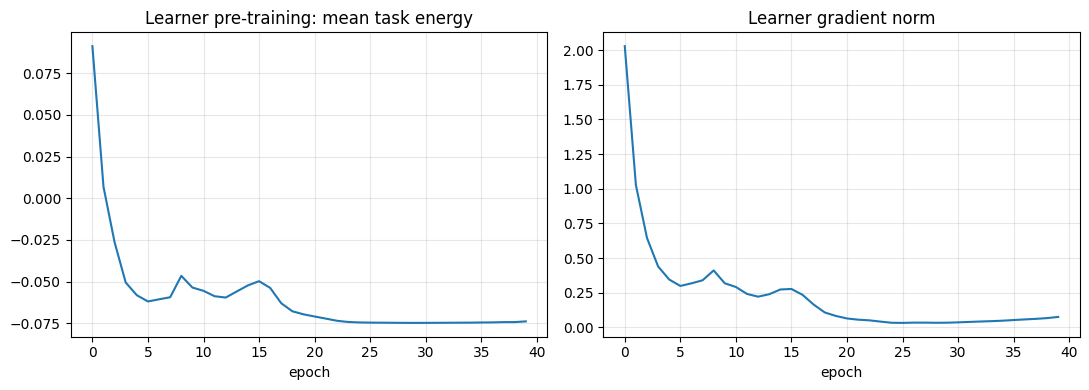

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_yukawa(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = (DEPTH, NUM_QUBITS, 3)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((eta, m), E0) in enumerate(zip(test_tasks, test_E0)):
    H = yukawa_hamiltonian(eta, m)
    print(f"task {ti}: eta={eta:.3f} m={m:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([eta, m], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_yukawa(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: eta=0.617 m=1.282  E0=-0.0743


task 1: eta=0.683 m=1.754  E0=-0.0665


task 2: eta=0.577 m=1.552  E0=-0.0536


task 3: eta=0.363 m=1.864  E0=-0.0176


task 4: eta=0.623 m=1.805  E0=-0.0537


task 5: eta=0.353 m=1.248  E0=-0.0249


saved


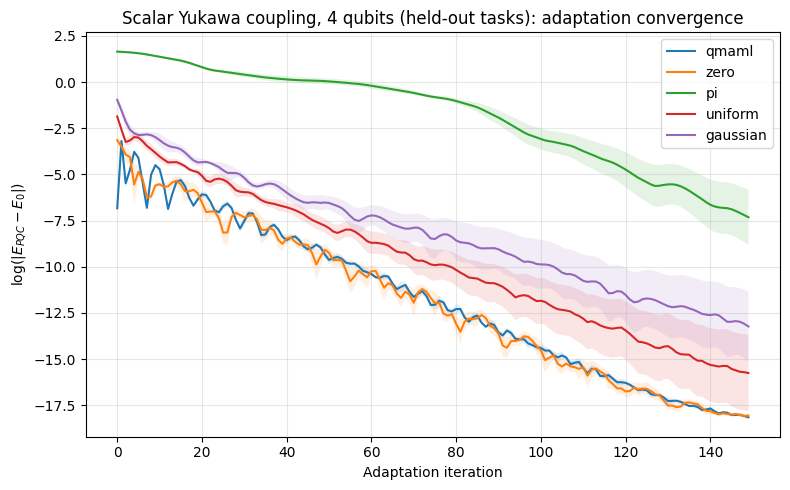

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-18.148   ~relative energy error=0.00%
  zero       log-gap=-18.051   ~relative energy error=0.00%
  pi         log-gap=-7.319   ~relative energy error=1.37%
  uniform    log-gap=-15.751   ~relative energy error=0.00%
  gaussian   log-gap=-13.230   ~relative energy error=0.00%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x_ax = np.arange(ADAPT_ITERS)
    ax.plot(x_ax, mean, label=scheme)
    ax.fill_between(x_ax, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Scalar Yukawa coupling, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 4. Findings

**Run:** 4 qubits (2 fermion + 2 boson, Lambda=4), depth 3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 150 adaptation iterations, single seed.

- **`qmaml` and `zero`-init tie for best, both reaching the float64 machine-precision floor** (final log-gap -18.148 and -18.051 respectively, ~0.00% relative error), with `uniform` close behind (-15.751), `gaussian` further back (-13.230), and `pi` clearly worst (-7.319, 1.37% error, still visibly descending at iteration 150 rather than converged).
- **Unlike almost every other track, `qmaml` does *not* have the best starting point here** -- `zero` (log-gap ~-3.1) and `uniform` (~-1.7) both start closer to the ground state than `qmaml` (~-6.9, plotted as $\log|E-E_0|$, so *more negative is better* -- `qmaml` actually starts worse in this run). `qmaml` and `zero` converge onto nearly identical, closely-tracking trajectories within about 10-15 iterations and stay locked together for the rest of the run.
- **A clean mechanistic explanation, not just an observation.** The task range was deliberately narrowed (Section 0) to keep the displacement $\eta/(2m)\lesssim0.5$, so every ground state in this experiment is a *small*-displacement, near-vacuum state (fermion vacuum, low mean boson number). `zero`-init's circuit at $\theta=0$ starts from exactly $|0000\rangle$ -- already close to the true ground state for small displacements. This plausibly explains both why `zero` is competitive here (a genuinely new pattern: on every Pauli-sum Hamiltonian in this project `zero` was an exact unmoving fixed point, and elsewhere on Hermitian-matrix Hamiltonians it ranged from not-stuck (scalar field) to a slow drift (SUSY QM) to an exact fixed point (D8 LGT) -- here it is not just unstuck but *competitive with the learned scheme*) and why `qmaml`, trained across this same narrow-displacement task distribution, ends up learning something close to the same answer.
- **`pi`-init is a clear, consistent loser here**, as it was on Track C's scalar field -- the second Hermitian-matrix Hamiltonian in this project where `pi` is the worst scheme by a wide margin, despite being competitive or best on several Pauli-sum gauge-theory tracks (A, B).
- **MVP vs. full plan:** fixed fermion mass $M=1$, boson truncation $\Lambda=4$ (matching the source paper's own "up to three bosons" showcase scale), task range deliberately narrowed to the truncation's <1%-accuracy regime (small $\eta/2m$) -- meaning this experiment specifically tests the *easy*, near-vacuum corner of the model's parameter space, which is plausibly why `zero`-init does so well here compared to every other track. Testing at larger $\eta/2m$ (which needs a larger boson truncation to stay accurate, per Section 0's own truncation-error curve) would be a sharper test of whether `qmaml`'s advantage reappears once the ground state moves further from the trivial vacuum, and is the natural next step.
